# El Observatorio Solar de Bacatá: Nuevas perspectivas Arqueo-astronómicas en el centro histórico de Bogotá

Este cuaderno reúne una serie de análisis geométricos y astronómicos basados en las coordenadas GPS de Iglesias históricas en La Candelaria, Bogotá.

Se exploran las alineaciones y triángulos formados por construcciones emblemáticas como el chorro de Quevedo, Monserrate y Guadalupe, aplicando correcciones por la curvatura de la Tierra y visualizaciones tanto en 2D como en 3D. Lineas de tiempo y otras graficas usadas para la publicacion "El Observatorio Solar de Bacatá: Nuevas perspectivas Arqueo-astronómicas en el centro histórico de Bogotá, ESpectra, 2026"

## 1. Configuración e Importación de Librerías
Importamos las librerías necesarias para cálculos matemáticos (`math`, `numpy`), optimización (`scipy`) y visualización (`matplotlib`).

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import minimize
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.cm as cm

# Configuración de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)

---

## 2. Definición de Datos y Funciones Geodésicas

Definimos las coordenadas GPS (latitud, longitud, altitud) de los principales puntos de interés y funciones para convertir entre sistemas de coordenadas.

In [2]:
# Constante: Radio medio de la Tierra en kilómetros
EARTH_RADIUS_KM = 6371.0

# Diccionario de triángulos: 'Nombre': [(lat, lon, alt), (lat, lon, alt), (lat, lon, alt)]
# Los puntos suelen corresponder a (Monserrate o Guadalupe, otro cerro, punto en la ciudad)
triangles = {
    "Chorro de Quevedo": [
        (4.591840782861174, -74.05436430808176, 3265),
        (4.605591310552596, -74.0555291341563, 3161),
        (4.597090245765097, -74.06983744529906, 2633)
    ],
    "Catedral Primada": [
        (4.591840782861174, -74.05436430808176, 3265),
        (4.605591310552596, -74.0555291341563, 3161),
        (4.598204386347961, -74.0752537684042, 2607)
    ],
    "Iglesia la Candelaria": [
        (4.591840782861174, -74.05436430808176, 3265),
        (4.605591310552596, -74.0555291341563, 3161),
        (4.59669227968629, -74.07258806859734, 2624)
    ],
    "Iglesia Egipto": [
        (4.591840782861174, -74.05436430808176, 3265),
        (4.605591310552596, -74.0555291341563, 3161),
        (4.593619554868877, -74.06896952527157, 2590)
    ],
    "San Francisco": [
        (4.591840782861174, -74.05436430808176, 3265),
        (4.605591310552596, -74.0555291341563, 3161),
        (4.601791021450818, -74.07321911962411, 2605)
    ]
}

def geodetic_to_ecef(lat_deg, lon_deg, alt_m=0):
    """
    Convierte coordenadas geodésicas (latitud, longitud, altitud en metros)
    a coordenadas cartesianas ECEF (x, y, z) en kilómetros.
    """
    lat = math.radians(lat_deg)
    lon = math.radians(lon_deg)
    alt_km = alt_m / 1000.0
    r = EARTH_RADIUS_KM + alt_km
    x = r * math.cos(lat) * math.cos(lon)
    y = r * math.cos(lat) * math.sin(lon)
    z = r * math.sin(lat)
    return np.array([x, y, z])

def ecef_to_geodetic(x, y, z):
    """
    Convierte coordenadas ECEF a geodésicas (lat, lon, alt_m).
    """
    r = np.linalg.norm([x, y, z])
    lat = math.asin(z / r)
    lon = math.atan2(y, x)
    alt_km = r - EARTH_RADIUS_KM
    return (math.degrees(lat), math.degrees(lon), alt_km * 1000)


---

## 3. Ejemplo de Cálculo de Distancia (Fórmula de Haversine)

La fórmula de Haversine permite calcular la distancia de "círculo máximo" entre dos puntos en una esfera, ideal para distancias GPS simples.

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia de círculo máximo entre dos puntos de la Tierra.
    Retorna la distancia en kilómetros.
    """
    # Convertir grados a radianes
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    
    return c * EARTH_RADIUS_KM

# Ejemplo de uso
pto_a = (4.3530, -74.0315)
pto_b = (4.3620, -74.0319)

dist = haversine_distance(pto_a[0], pto_a[1], pto_b[0], pto_b[1])
print(f"Distancia entre A y B: {dist:.4f} km ({dist*1000:.2f} metros)")

Distancia entre A y B: 1.0017 km (1001.74 metros)


---

## 4. Cálculo de Ángulos en 3D

Para mayor precisión, convertimos las coordenadas GPS a un sistema cartesiano 3D (ECEF) que tiene en cuenta la altura y la curvatura terrestre. Calculamos los ángulos internos de los triángulos formados por los hitos.

In [4]:
def calculate_angle_3d(A, B, C):
    """
    Calcula el ángulo en el vértice B formado por los puntos A, B y C.
    """
    BA = A - B
    BC = C - B
    
    # Producto punto y normas
    cos_angle = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC))
    cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Evitar errores numéricos fuera de dominio
    
    angle_rad = math.acos(cos_angle)
    return math.degrees(angle_rad)

print(f"| {'Triángulo':<24} | {'Ángulo 1 (A)':<12} | {'Ángulo 2 (B)':<12} | {'Ángulo 3 (C)':<12} |")
print("|" + "-"*26 + "|" + "-"*14 + "|" + "-"*14 + "|" + "-"*14 + "|")

results = {}

for name, points in triangles.items():
    # Convertir a ECEF
    A = geodetic_to_ecef(*points[0])
    B = geodetic_to_ecef(*points[1])
    C = geodetic_to_ecef(*points[2])

    angle_A = calculate_angle_3d(B, A, C)
    angle_B = calculate_angle_3d(A, B, C)
    angle_C = calculate_angle_3d(A, C, B)
    
    # Guardamos los ángulos para usarlos luego en plots
    results[name] = (angle_A, angle_B, angle_C)

    print(f"| {name:<24} | {angle_A:10.2f}° | {angle_B:10.2f}° | {angle_C:10.2f}° |")

| Triángulo                | Ángulo 1 (A) | Ángulo 2 (B) | Ángulo 3 (C) |
|--------------------------|--------------|--------------|--------------|
| Chorro de Quevedo        |      66.43° |      66.33° |      47.24° |
| Catedral Primada         |      67.94° |      75.63° |      36.43° |
| Iglesia la Candelaria    |      69.96° |      69.00° |      41.04° |
| Iglesia Egipto           |      77.63° |      56.07° |      46.31° |
| San Francisco            |      57.47° |      83.99° |      38.54° |


### Gráfico 2D con Arcos de Ángulos
Visualizamos los triángulos proyectados en latitud/longitud, indicando el valor del tercer ángulo calculado.

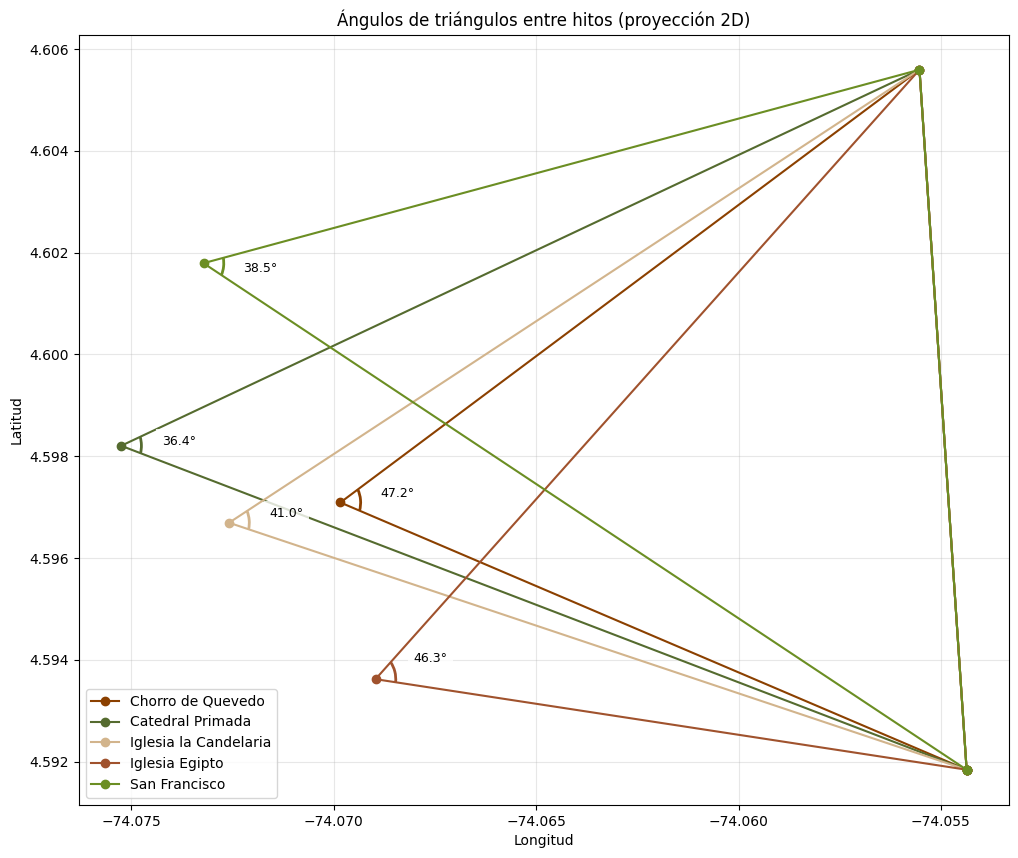

In [5]:
terra_colors = ["#8B4000", "#556B2F", "#D2B48C", "#A0522D", "#6B8E23"]

plt.figure(figsize=(12, 10))
ax = plt.gca()

def draw_angle_arc(vertex, adj1, adj2, color, radius=0.0005):
    # Vectores dirección en 2D
    v1 = adj1 - vertex
    v2 = adj2 - vertex
    ang1 = math.degrees(math.atan2(v1[1], v1[0])) % 360
    ang2 = math.degrees(math.atan2(v2[1], v2[0])) % 360
    
    if ang2 < ang1: ang2 += 360
    arc_angle = ang2 - ang1
    if arc_angle > 180: 
        ang1, ang2 = ang2, ang1 + 360

    arc = Arc((vertex[0], vertex[1]), width=radius*2, height=radius*2,
              angle=0, theta1=ang1, theta2=ang2, color=color, lw=2)
    ax.add_patch(arc)

def angle_text_pos(vertex, adj1, adj2, offset=0.001):
    v1 = adj1 - vertex
    v2 = adj2 - vertex
    direction = (v1 + v2)
    norm = np.linalg.norm(direction)
    if norm > 0: direction /= norm
    return vertex + direction * offset

for i, (name, points) in enumerate(triangles.items()):
    color = terra_colors[i % len(terra_colors)]
    
    # Coordenadas 2D para plot
    lats = [p[0] for p in points]
    lons = [p[1] for p in points]
    # Cerrar polígono
    lats.append(points[0][0])
    lons.append(points[0][1])
    
    plt.plot(lons, lats, marker='o', linestyle='-', color=color, label=name)
    
    # Vectores numpy 2D (lon, lat) para utilidades de dibujo
    P0 = np.array([points[0][1], points[0][0]])
    P1 = np.array([points[1][1], points[1][0]])
    P2 = np.array([points[2][1], points[2][0]])
    
    # Dibujar arco en el tercer punto (P2)
    draw_angle_arc(P2, P0, P1, color)
    
    # Etiqueta del ángulo
    angle_val = results[name][2]
    pos = angle_text_pos(P2, P0, P1)
    plt.text(pos[0], pos[1], f'{angle_val:.1f}°', fontsize=9, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('Ángulos de triángulos entre hitos (proyección 2D)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

---

## 5. Búsqueda del "Triángulo Ideal"

Dado un triángulo con dos puntos fijos (A y B) y tres ángulos internos conocidos, pero con el tercer punto (C) desconocido, utilizamos optimización numérica para encontrar las coordenadas de C.

In [6]:
def angular_distance(vec1, vec2):
    """Distancia angular entre dos vectores ECEF."""
    cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return math.acos(cos_angle)

# Puntos fijos A y B
A_lat, A_lon, A_alt = 4.591840782861174, -74.05436430808176, 3265
B_lat, B_lon, B_alt = 4.605591310552596, -74.0555291341563, 3161
C_alt_m = 2630  # Altura fija asumida para C

# Ángulos objetivo del triángulo
target_angle_A = math.radians(67.1)
target_angle_B = math.radians(67.2)
target_angle_C = math.radians(45.7)

# Convertir fijos a ECEF
A_ecef = geodetic_to_ecef(A_lat, A_lon, A_alt)
B_ecef = geodetic_to_ecef(B_lat, B_lon, B_alt)

# Calcular lado 'c' (arco AB)
side_c = angular_distance(A_ecef, B_ecef)

# Ley de Senos Esférica para estimar lados 'a' y 'b'
side_a = side_c * math.sin(target_angle_A) / math.sin(target_angle_C)
side_b = side_c * math.sin(target_angle_B) / math.sin(target_angle_C)

def objective(coord):
    """
    Función de error a minimizar.
    Busca lat/lon tal que las distancias angulares a A y B coincidan con lo calculado.
    """
    lat_deg, lon_deg = coord
    C_ecef_guess = geodetic_to_ecef(lat_deg, lon_deg, C_alt_m)
    
    dist_to_A = angular_distance(C_ecef_guess, A_ecef)
    dist_to_B = angular_distance(C_ecef_guess, B_ecef)
    
    return (dist_to_A - side_b)**2 + (dist_to_B - side_a)**2

# Estimación inicial (promedio)
init_guess = [(A_lat + B_lat) / 2, (A_lon + B_lon) / 2]

# Optimizar
res = minimize(objective, init_guess, method='Nelder-Mead')

C_sol_lat, C_sol_lon = res.x
print("Solución encontrada para el punto C:")
print(f"Latitud: {C_sol_lat:.6f}°, Longitud: {C_sol_lon:.6f}°, Altura: {C_alt_m}m")

Solución encontrada para el punto C:
Latitud: 4.597385°, Longitud: -74.071324°, Altura: 2630m


---

## 6. Visualización 3D

Representación tridimensional de los triángulos utilizando las coordenadas cartesianas ECEF.

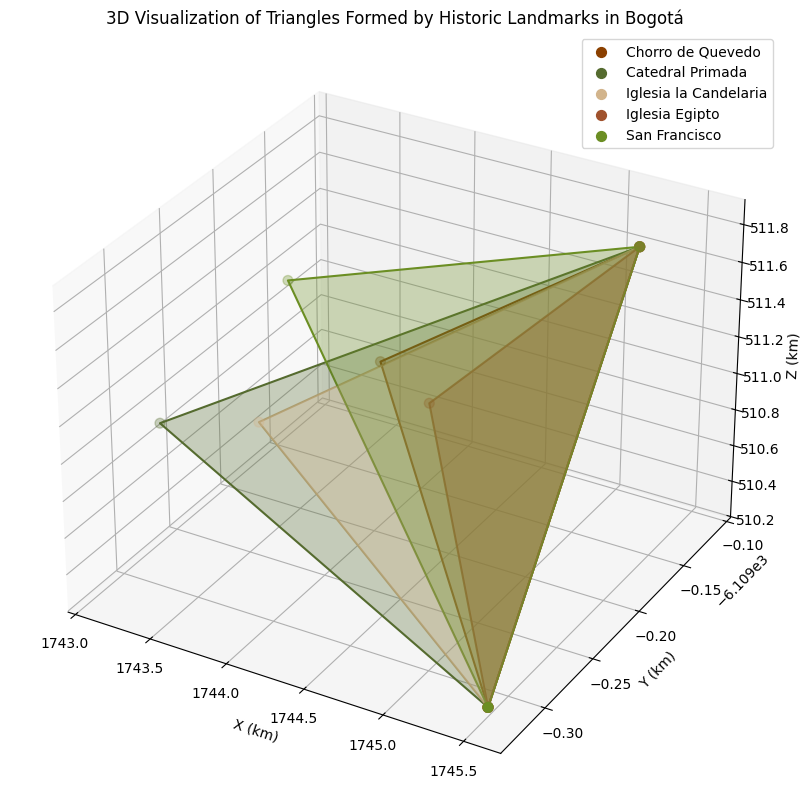

In [7]:
# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
colors = ['#8B4000', '#556B2F', '#D2B48C', '#A0522D', '#6B8E23']

for i, (name, points) in enumerate(triangles.items()):
    # Convert GPS points to ECEF
    ecef_points = np.array([geodetic_to_ecef(*p) for p in points])
    
    # Plot vertices
    ax.scatter(ecef_points[:, 0], ecef_points[:, 1], ecef_points[:, 2], label=name, color=colors[i % len(colors)], s=50)
    
    # Draw triangle edges
    tri_edges = np.vstack([ecef_points, ecef_points[0]])  # Close the triangle loop
    ax.plot(tri_edges[:, 0], tri_edges[:, 1], tri_edges[:, 2], color=colors[i % len(colors)])
    
    # Draw filled triangle with some transparency
    verts = [list(ecef_points)]
    ax.add_collection3d(Poly3DCollection(verts, alpha=0.3, facecolor=colors[i % len(colors)]))

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('3D Visualization of Triangles Formed by Historic Landmarks in Bogotá')
ax.legend()
plt.show()

---

## 7. Línea de Tiempo Histórica

Visualización cronológica de la fundación de los hitos importantes mencionados.

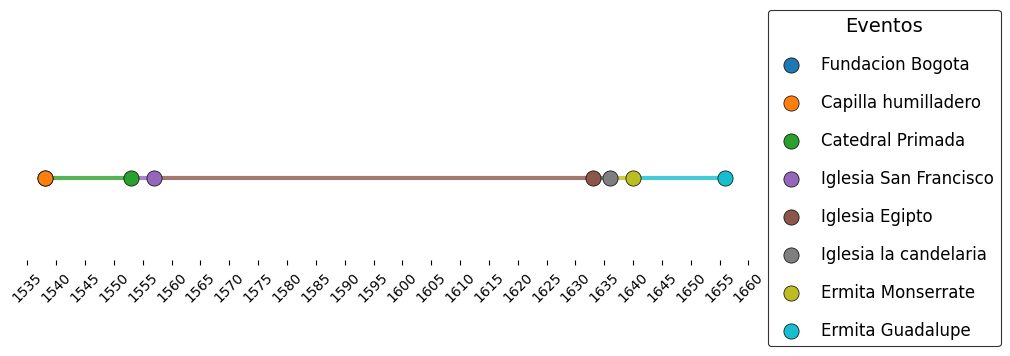

In [8]:
# Eventos ordenados cronológicamente (fecha, etiqueta)
events = [
    ("1538-01-01", "Fundacion Bogota"),
    ("1538-01-01", "Capilla humilladero"),
    ("1553-01-01", "Catedral Primada"),
    ("1557-01-01", "Iglesia San Francisco"),
    ("1633-01-01", "Iglesia Egipto"),
    ("1636-01-01", "Iglesia la candelaria"),
    ("1640-01-01", "Ermita Monserrate"),
    ("1656-01-01", "Ermita Guadalupe")
]

# Parámetros editables
point_size = 120         # Tamaño de los puntos
line_width = 3           # Grosor de las líneas
font_size_legend = 12    # Tamaño fuente leyenda

# Convertir fechas a datetime
dates = [datetime.strptime(date, "%Y-%m-%d") for date, _ in events]
labels = [label for _, label in events]

# Colores de la paleta terrain, distribuidos uniformemente
cmap = plt.get_cmap('tab10')  # Colores más contrastantes para fondo blanco
colors = [cmap(i / (len(events) - 1)) for i in range(len(events))]

fig, ax = plt.subplots(figsize=(12, 3))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Dibujar líneas coloreadas antes de cada punto
for i in range(1, len(dates)):
    ax.hlines(1, dates[i-1], dates[i], color=colors[i], linewidth=line_width, zorder=2, alpha=0.8)

# Dibujar puntos con label para la leyenda
for date, label, color in zip(dates, labels, colors):
    ax.scatter(date, 1, color=color, s=point_size, label=label, zorder=3, edgecolors='black', linewidth=0.5)

# Configurar eje x para mostrar solo años con ticks cada 5 años
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))  # Tick cada 5 años
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(color='black', rotation=45)

# Limpiar eje y y bordes
ax.yaxis.set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Crear leyenda lateral con texto blanco y fondo negro
leg = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),
                fontsize=font_size_legend, frameon=True, labelspacing=1.2,
                title="Eventos", title_fontsize=font_size_legend+2)

# Cambiar color del texto de la leyenda a blanco
for text in leg.get_texts():
    text.set_color('black')

# Cambiar color del título de la leyenda a blanco
leg.get_title().set_color('black')

# Cambiar fondo y borde de la leyenda para que contraste con el fondo negro
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(0.8)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Deja espacio para la leyenda a la derecha
plt.show()